In [1]:
import tensorflow as tf
from tensorflow.keras import backend as K

# 1️⃣ Clear any previous session to free memory
K.clear_session()
tf.compat.v1.reset_default_graph()  # optional, for TF1 compatibility
print("Cleared previous TensorFlow session.")

# 2️⃣ Limit GPU memory growth (avoids allocating all GPU memory at once)
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2025-11-19 19:51:19.897054: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 19:51:20.068762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763560280.133759    1793 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763560280.153175    1793 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763560280.296363    1793 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Cleared previous TensorFlow session.


In [2]:
# Utility

from shutil import copyfile, copy
import matplotlib.pyplot as plt
import IPython.display as ipd
import os
import pandas as pd
import numpy as np
import itertools

# Audio processing
import librosa
import librosa.display
import audiomentations

# Sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Keras
import keras
from keras import regularizers
from keras.regularizers import l2
from keras.models import Sequential, Model
from keras.layers import Input, Flatten, Dropout, Dense, Activation, LeakyReLU, Conv1D, MaxPooling1D
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# Initialize lists
emotion = []
path = []

In [4]:
dir_path= '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24'
# List all files in directory and subdirectories
file_list = []
for root, dirs, files in os.walk(dir_path):
    for file in files:
        if file.endswith('.wav'):  # only audio files
            file_list.append(os.path.join(root, file))

# Sort the list
file_list.sort()

# Check the first few files
print(file_list[:10])

['/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-02-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-02-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-02-02-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-02-01-01-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-02-01-01-02-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-02-01-02-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-02-01-02-02-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-02-02-01-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_0

In [5]:
def switch(val):
    # Example mapping based on RAVDESS (1-8)
    mapping = {
        1: 'neutral',
        2: 'calm',
        3: 'happy',
        4: 'sad',
        5: 'angry',
        6: 'fearful',
        7: 'disgust',
        8: 'surprised'
    }
    return mapping.get(val, 'unknown')

In [6]:
# Loop over all actor folders
for actor_folder in os.listdir(dir_path):
    actor_path = os.path.join(dir_path, actor_folder)
    if os.path.isdir(actor_path):
        # List all wav files in this actor folder
        for f in os.listdir(actor_path):
            if f.endswith('.wav'):
                id_parts = f[:-4].split('-')  # Remove .wav and split by '-'
                if id_parts[2] != '01':       # Exclude neutral intensity (01)
                    emotion.append(switch(int(id_parts[2])))
                    path.append(os.path.join(actor_path, f))

# Check first few entries
print(emotion[:10])
print(path[:10])

['disgust', 'fearful', 'happy', 'angry', 'surprised', 'angry', 'surprised', 'disgust', 'calm', 'calm']
['/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-07-01-02-01-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-06-01-02-02-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-03-01-02-01-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-05-02-02-02-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-08-01-01-02-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-05-01-02-01-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-08-01-02-02-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_24/03-01-07-02-01-01-24.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01

In [7]:
# Create DataFrame from emotion and path lists
df = pd.concat([pd.DataFrame(emotion), pd.DataFrame(path)], axis=1)
df.columns = ['emotion', 'path']

# Count number of samples per emotion
print(df['emotion'].value_counts())

emotion
disgust      192
fearful      192
happy        192
angry        192
surprised    192
calm         192
sad          192
Name: count, dtype: int64


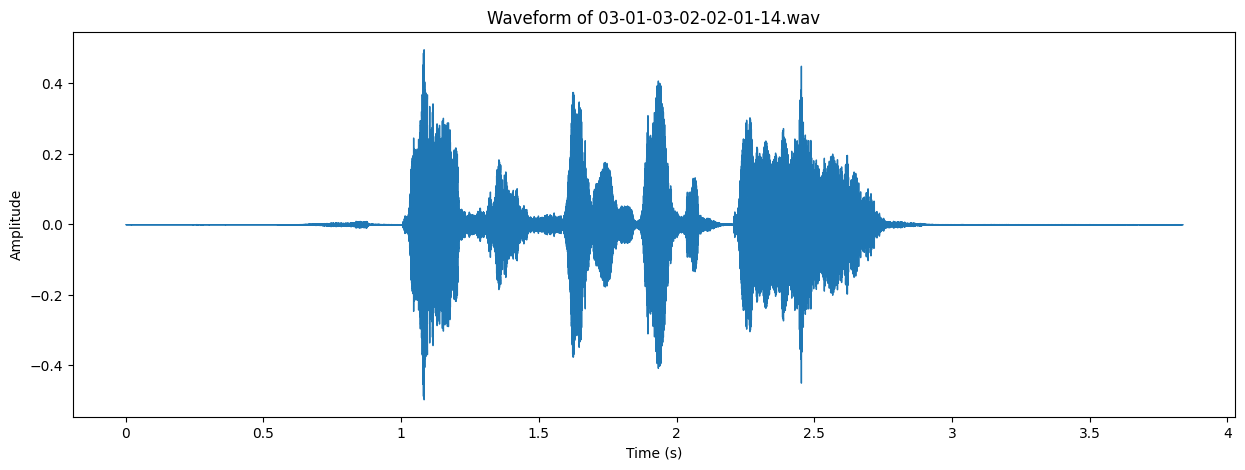

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import os

# Example: one specific audio file
filename = '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_14/03-01-03-02-02-01-14.wav'

# Load audio
data, sampling_rate = librosa.load(filename, sr=None)  # sr=None preserves original sampling rate

# Plot waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform of " + os.path.basename(filename))
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play audio
ipd.Audio(filename)


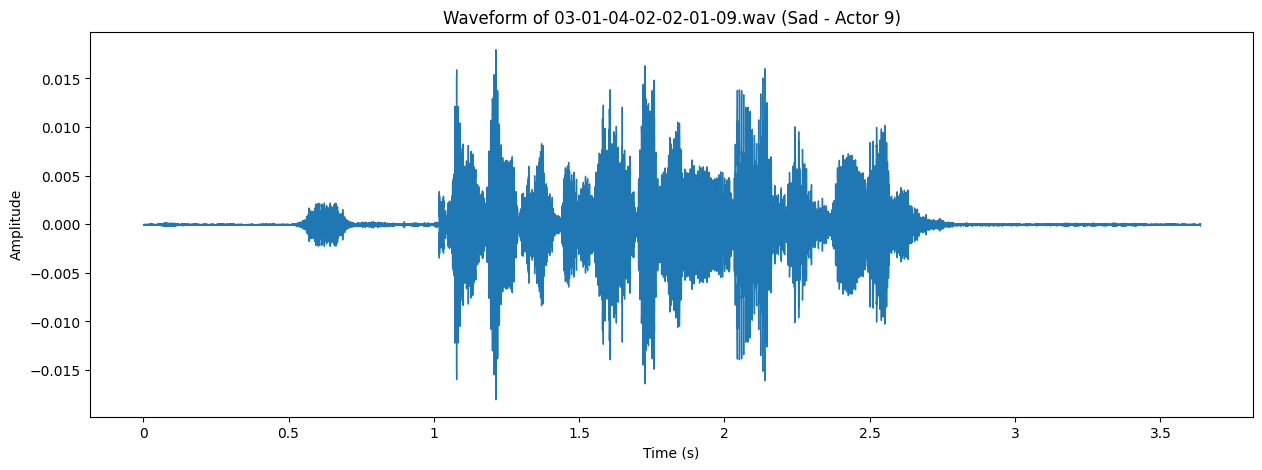

In [10]:
# Sad - Actor 9
filename = '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_09/03-01-04-02-02-01-09.wav'

# Load audio
data, sampling_rate = librosa.load(filename, sr=None)  # sr=None preserves original sampling rate

# Plot waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform of " + os.path.basename(filename) + " (Sad - Actor 9)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play audio
ipd.Audio(filename)

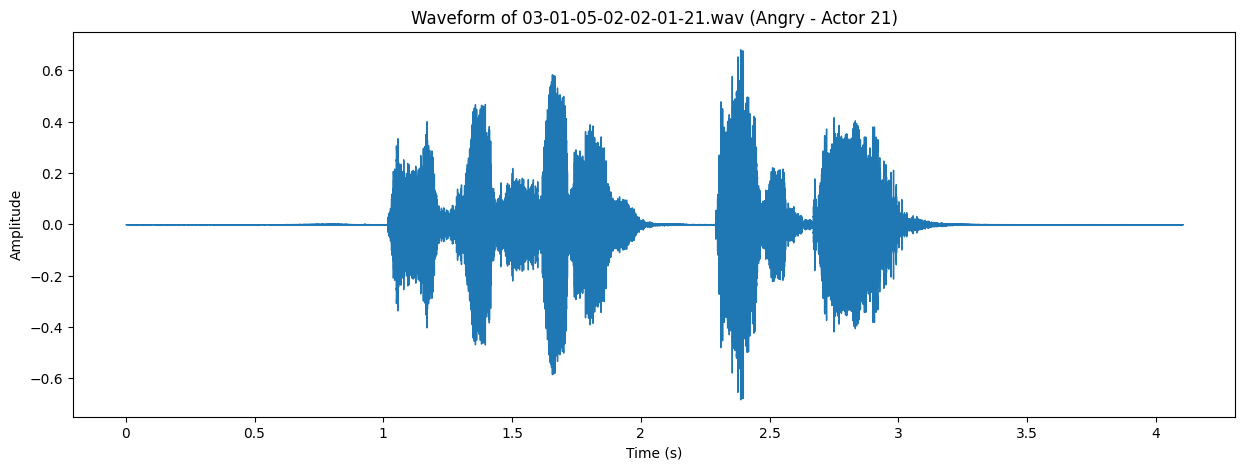

In [11]:
# Angry - Actor 21
filename = '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_21/03-01-05-02-02-01-21.wav'

# Load audio
data, sampling_rate = librosa.load(filename, sr=None)  # sr=None preserves original sampling rate

# Plot waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform of " + os.path.basename(filename) + " (Angry - Actor 21)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play audio
ipd.Audio(filename)

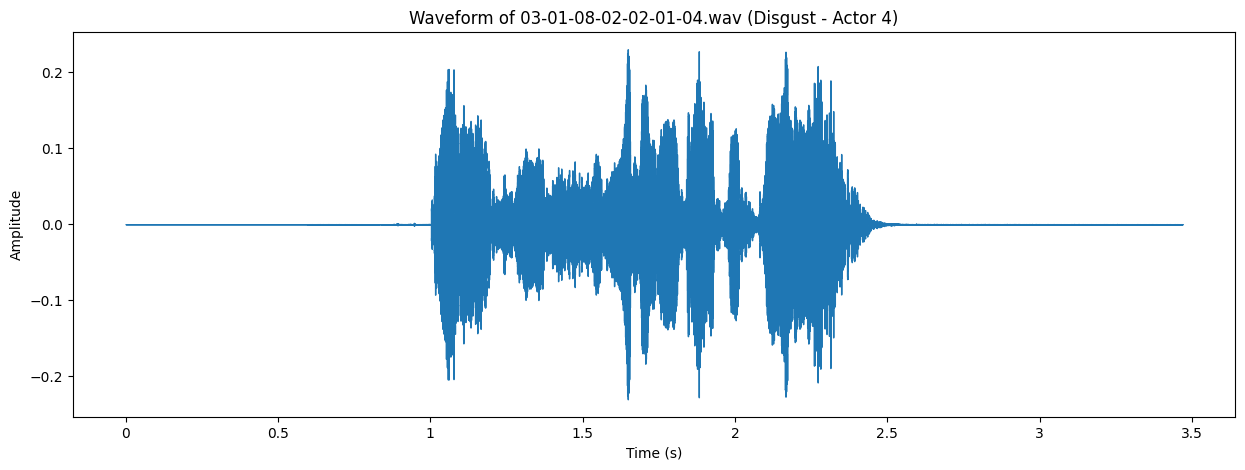

In [12]:
# Disgust - Actor 4
filename = '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_04/03-01-08-02-02-01-04.wav'

# Load audio
data, sampling_rate = librosa.load(filename, sr=None)  # sr=None preserves original sampling rate

# Plot waveform
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform of " + os.path.basename(filename) + " (Disgust - Actor 4)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play audio
ipd.Audio(filename)

In [13]:
import librosa
import numpy as np

duration = []  # duration in seconds
rate = []      # sampling rates

for filename in df['path']:
    data, sampling_rate = librosa.load(filename, sr=None)  # Keep original sample rate
    duration.append(data.shape[0] / sampling_rate)         # convert samples to seconds
    rate.append(sampling_rate)

print("Unique durations (seconds):", np.unique(np.round(duration, 3)))
print("Unique sampling rates:", np.unique(rate))


Unique durations (seconds): [2.936 2.97  3.003 3.036 3.07  3.103 3.136 3.17  3.203 3.237 3.27  3.303
 3.337 3.37  3.403 3.437 3.47  3.504 3.537 3.57  3.604 3.637 3.67  3.704
 3.737 3.77  3.804 3.837 3.871 3.904 3.937 3.971 4.004 4.037 4.071 4.104
 4.137 4.171 4.204 4.238 4.271 4.304 4.338 4.371 4.404 4.438 4.471 4.504
 4.538 4.571 4.605 4.638 4.671 4.738 4.771 4.805 4.838 4.872 4.905 4.938
 5.005 5.105 5.272]
Unique sampling rates: [48000]


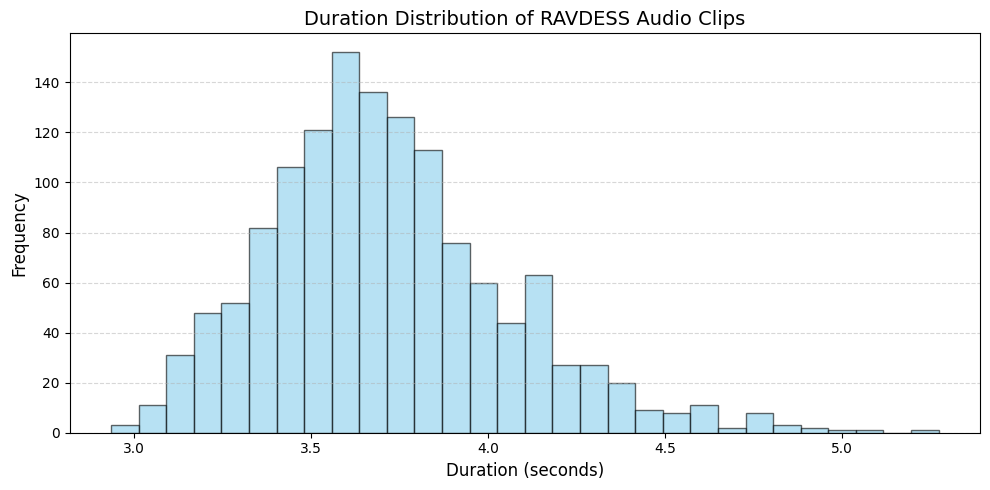

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(duration, bins=30, alpha=0.6, color='skyblue', edgecolor='black', histtype='bar')
plt.title('Duration Distribution of RAVDESS Audio Clips', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:
import numpy as np

mean_duration = np.mean(duration)
min_duration = np.min(duration)
max_duration = np.max(duration)

print(f"Mean Duration: {round(mean_duration, 2)} seconds")
print(f"Minimum Duration: {round(min_duration, 2)} seconds")
print(f"Maximum Duration: {round(max_duration, 2)} seconds")


Mean Duration: 3.71 seconds
Minimum Duration: 2.94 seconds
Maximum Duration: 5.27 seconds


# Data processing

In [16]:
audio_data = []

for filename in df['path']:
    # Load audio with native sampling rate
    data, sampling_rate = librosa.load(filename, sr=None, duration=3, offset=0.5)
    audio_data.append(data)

# Add audio as a new column in the DataFrame
df['data'] = audio_data

# Check DataFrame
print(df.head())
print(df['data'][0].shape) 

df.head()

     emotion                                               path  \
0    disgust  /home/heru/sonamyangchen/ravdess_emotion/Audio...   
1    fearful  /home/heru/sonamyangchen/ravdess_emotion/Audio...   
2      happy  /home/heru/sonamyangchen/ravdess_emotion/Audio...   
3      angry  /home/heru/sonamyangchen/ravdess_emotion/Audio...   
4  surprised  /home/heru/sonamyangchen/ravdess_emotion/Audio...   

                                                data  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, -3.0517578e-05, 0.0, 0.0, 0.0, 0.0,...  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
(144000,)


,emotion,path,data
0,disgust,/home/heru/sonamyangchen/ravdess_emotion/Audio...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,fearful,/home/heru/sonamyangchen/ravdess_emotion/Audio...,"[0.0, 0.0, -3.0517578e-05, 0.0, 0.0, 0.0, 0.0,..."
2,happy,/home/heru/sonamyangchen/ravdess_emotion/Audio...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,angry,/home/heru/sonamyangchen/ravdess_emotion/Audio...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,surprised,/home/heru/sonamyangchen/ravdess_emotion/Audio...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [17]:
import numpy as np

target_length = 144000  # 3 seconds at 48 kHz

for i in range(len(df)):
    audio_clip = df.at[i, 'data']  # safer than df['data'][i]
    current_len = len(audio_clip)
    
    if current_len < target_length:
        # Pad equally at start and end
        start_pad = (target_length - current_len) // 2
        end_pad = target_length - current_len - start_pad
        df.at[i, 'data'] = np.pad(audio_clip, (start_pad, end_pad), mode='constant')
    elif current_len > target_length:
        # Truncate equally from start and end
        start_cut = (current_len - target_length) // 2
        end_cut = start_cut + target_length
        df.at[i, 'data'] = audio_clip[start_cut:end_cut]

# Verify all audio lengths
print(np.unique([len(x) for x in df['data']]))


[144000]


In [18]:
for i in range(len(df)):
    if len(df.at[i, 'data']) != 144000:
        print(f"Index {i} has length {len(df.at[i, 'data'])}")


# Feature extraction

In [19]:
def feature_extractor(audio, feature='mel', sr=48000):
    if feature == 'mel':
        # Compute Mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio.astype(float),
            sr=sr,
            n_fft=1024,
            hop_length=512,
            n_mels=128,
            fmin=50,
            fmax=24000
        )
        # Convert to log scale (dB)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)
        # Take mean over time frames (axis=1)
        return np.mean(mel_db, axis=1)

    else:
        raise ValueError(f"Feature '{feature}' not supported yet.")

In [20]:
# Initialize an empty list to store features
features_list = []

for i in range(len(df)):
    mel = feature_extractor(df.at[i, 'data'], feature='mel')  # safer than df['data'][i]
    features_list.append(mel)

# Add as a new column
df['features'] = features_list

# Check the first feature vector
print(df['features'][0].shape)  

(128,)


In [21]:
print('We obtained a matrix with ' + str(len(df)) + ' samples and ' + str(len(df['features'][0])) + ' features.')
     

We obtained a matrix with 1344 samples and 128 features.


In [22]:
# Select test set
X_test = df['features'][1120:1344].reset_index(drop=True)
y_test = df['emotion'][1120:1344].reset_index(drop=True)

# Optional: convert to NumPy arrays for model input
X_test = np.stack(X_test.values)  # shape: (224, 128)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_test shape: (224, 128)
y_test shape: (224,)


In [23]:
df = df[:1120]

# Data augmentation

In [24]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

noise = audiomentations.Compose([
    audiomentations.AddGaussianNoise(p = 1)
])


In [25]:
df['features_aug1'] = [0] * 1120
for i in range(len(df)):
  augmented_samples = noise(df['data'][i], 48000)
  mel = feature_extractor(augmented_samples, 'mel')
  df['features_aug1'][i] = np.array(mel, dtype = object)

/tmp/ipykernel_1793/2325939030.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['features_aug1'][i] = np.array(mel, dtype = object)
/tmp/ipykernel_1793/2325939030.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [26]:
pitchShift = audiomentations.Compose([
    audiomentations.PitchShift(p = 1)
])
     

In [27]:
df['features_aug2'] = [0] * 1120
for i in range(len(df)):
  augmented_samples = pitchShift(df['data'][i], 48000)
  mel = feature_extractor(augmented_samples, 'mel')
  df['features_aug2'][i] = np.array(mel, dtype = object)

/tmp/ipykernel_1793/13131741.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['features_aug2'][i] = np.array(mel, dtype = object)
/tmp/ipykernel_1793/13131741.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [28]:
stretch = audiomentations.Compose([
    audiomentations.TimeStretch(p = 1)
])

In [29]:
df['features_aug3'] = [0] * 1120
for i in range(len(df)):
  augmented_samples = stretch(df['data'][i], 48000)
  mel = feature_extractor(augmented_samples, 'mel')
  df['features_aug3'][i] = np.array(mel, dtype = object)

/tmp/ipykernel_1793/2933268621.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['features_aug3'][i] = np.array(mel, dtype = object)
/tmp/ipykernel_1793/2933268621.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [30]:
from audiomentations import Compose, Shift

augment = Compose([
    Shift(min_shift=0.25, max_shift=0.25, shift_unit="fraction", rollover=False, p=1.0)
])


In [31]:
df['features_aug4'] = [0] * 1120

for i in range(len(df)):
    augmented_samples = augment(samples=df['data'][i], sample_rate=48000)
    mel = feature_extractor(augmented_samples, 'mel')
    df['features_aug4'][i] = np.array(mel, dtype=object)


/tmp/ipykernel_1793/2695133481.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['features_aug4'][i] = np.array(mel, dtype=object)
/tmp/ipykernel_1793/2695133481.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [32]:

final_df = pd.concat([
    pd.concat([df['path'], df['path'], df['path'], df['path'], df['path']], axis = 0),
    pd.concat([df['emotion'], df['emotion'], df['emotion'], df['emotion'], df['emotion']], axis = 0),
    pd.concat([df['data'], df['data'], df['data'], df['data'], df['data']], axis = 0),
    pd.concat([df['features'], df['features_aug1'], df['features_aug2'], df['features_aug3'], df['features_aug4']], axis = 0)
], axis = 1)
final_df.rename(columns = {0: 'features'}, inplace = True)
final_df.reset_index (drop = True, inplace = True)
     

In [33]:

final_df.head()

,path,emotion,data,features
0,/home/heru/sonamyangchen/ravdess_emotion/Audio...,disgust,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-64.77003342171571, -60.145404080477945, -54...."
1,/home/heru/sonamyangchen/ravdess_emotion/Audio...,fearful,"[0.0, 0.0, -3.0517578e-05, 0.0, 0.0, 0.0, 0.0,...","[-66.10898862026123, -65.86269171564462, -64.7..."
2,/home/heru/sonamyangchen/ravdess_emotion/Audio...,happy,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-63.96162528677128, -61.19179223297639, -57.4..."
3,/home/heru/sonamyangchen/ravdess_emotion/Audio...,angry,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-70.5994373257876, -69.06904688374686, -65.72..."
4,/home/heru/sonamyangchen/ravdess_emotion/Audio...,surprised,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-69.04880568657322, -68.09138474248677, -65.7..."


In [34]:
print('We obtained a matrix with ' + str(len(final_df)) + ' samples and ' + str(len(final_df['features'][0])) + ' features.')
     

We obtained a matrix with 5600 samples and 128 features.


# Split train-test

In [35]:
X_train =  final_df['features'].tolist()
y_train = final_df['emotion'].tolist()
X_test = X_test.tolist()
y_test = y_test.tolist()

In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Convert features column to numpy arrays
X_train = [np.array(x, dtype=np.float64) for x in final_df['features']]
y_train = final_df['emotion'].tolist()

X_test = [np.array(x, dtype=np.float64) for x in X_test]   # OK
# y_test = y_test.tolist()  # ❌ remove this

# Convert to 2D (samples, features)
X_train = np.vstack(X_train)
X_test = np.vstack(X_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [37]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [38]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder


In [39]:
# One-hot encode the target 
lb = LabelEncoder()
y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.transform(y_test))

In [40]:
# Making data compatible for the model
X_train = np.expand_dims(X_train, axis = 2)
X_test = np.expand_dims(X_test, axis = 2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5600, 128, 1), (5600, 7), (224, 128, 1), (224, 7))

# Model 2: augmented data
Now let's return to the original model and compare the performances if we use augmented data.

In [41]:
# We don't have to pick the validation data augmented
X_train_aug = np.concatenate((X_train[0:896], X_train[1120:1120+896], X_train[2240:2240+896], 
                                  X_train[3360:3360+896], X_train[4480:4480+896]
                                  ), axis = 0)
y_train_aug = np.concatenate((y_train[0:896], y_train[1120:1120+896], y_train[2240:2240+896], 
                                  y_train[3360:3360+896],y_train[4480:4480+896]
                                  ), axis = 0)

In [44]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU, BatchNormalization


# Clear previous models & set random seed
K.clear_session()
tf.random.set_seed(42)

# Split training data into train + validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

num_classes = 7
model2 = Sequential()

# Conv Block 1
model2.add(Conv1D(64, kernel_size=10, padding='same', input_shape=(X_train.shape[1], 1)))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Conv Block 2
model2.add(Conv1D(128, kernel_size=10, padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Conv Block 3
model2.add(Conv1D(128, kernel_size=10, padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Fully Connected
model2.add(Flatten())
model2.add(Dense(128))
model2.add(LeakyReLU(0.1))
model2.add(Dropout(0.5))

# Output layer
model2.add(Dense(num_classes, activation='softmax'))

model2.summary()


/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763560633.599012    1793 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13709 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,175 (1.95 MB)

 Trainable params: 510,535 (1.95 MB)

 Non-trainable params: 640 (2.50 KB)

In [45]:
# Early stopping
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Compile the model
model2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Fit the model
history2 = model2.fit(
    X_train_final,
    y_train_final,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1
)

Epoch 1/100


I0000 00:00:1763560635.083486    3127 service.cc:152] XLA service 0x7486440122e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763560635.083511    3127 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-11-19 19:57:15.122560: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763560635.287452    3127 cuda_dnn.cc:529] Loaded cuDNN version 91600


 80/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2032 - loss: 2.4160

I0000 00:00:1763560637.849521    3127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2147 - loss: 2.2779 - val_accuracy: 0.1920 - val_loss: 1.9449
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3075 - loss: 1.8195 - val_accuracy: 0.1821 - val_loss: 2.2784
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3909 - loss: 1.6196 - val_accuracy: 0.2732 - val_loss: 1.9586
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4392 - loss: 1.5046 - val_accuracy: 0.4232 - val_loss: 1.4978
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4666 - loss: 1.3967 - val_accuracy: 0.5232 - val_loss: 1.2818
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5011 - loss: 1.3106 - val_accuracy: 0.5688 - val_loss: 1.2060
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5263 - loss: 1.2550 - val_accuracy: 0.6045 - val_loss: 1.0869
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5574 - loss: 1.1634 - val_accuracy: 0.6098

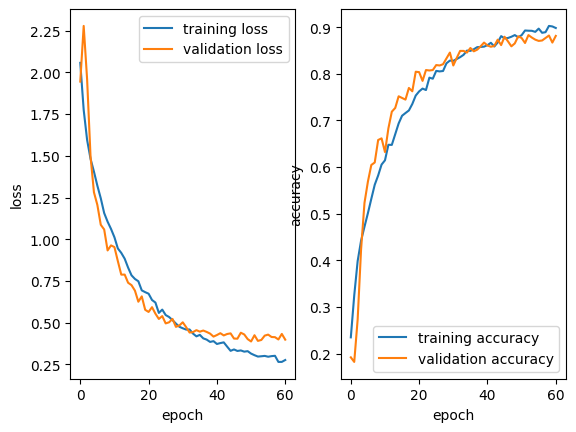

In [46]:
plt.subplot(1,2,1)
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training loss', 'validation loss'])

plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['training accuracy', 'validation accuracy'])

In [47]:
y_pred = model2.predict(X_val)
y_pred_ = np.argmax(y_pred, axis = 1)
y_val_ = np.argmax(y_val, axis = 1)
print(classification_report(y_val_, y_pred_))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       160
           1       0.83      0.96      0.89       160
           2       0.87      0.90      0.89       160
           3       0.90      0.83      0.87       160
           4       0.89      0.82      0.85       160
           5       0.88      0.81      0.84       160
           6       0.85      0.94      0.89       160

    accuracy                           0.88      1120
   macro avg       0.88      0.88      0.88      1120
weighted avg       0.88      0.88      0.88      1120



Text(0, 0.5, 'Prediction')

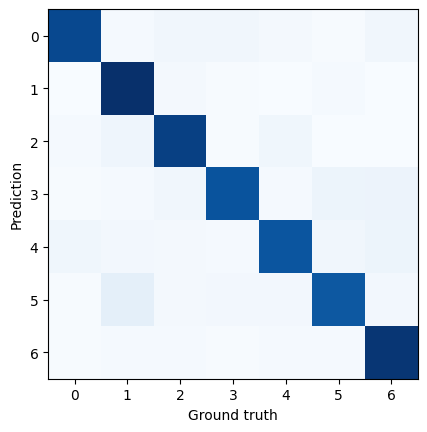

In [48]:
cm = confusion_matrix(y_val_, y_pred_)
plt.imshow(cm, cmap = plt.cm.Blues)
plt.xlabel('Ground truth')
plt.ylabel('Prediction')
     

In [49]:
print(top_k_accuracy_score(y_val_, y_pred, k = 2))
print(top_k_accuracy_score(y_val_, y_pred, k = 3))

0.9410714285714286
0.9660714285714286


# Grid search CV
Let's perform a grid search on the basis of a 5-Folds Cross-Validation in the same way as above.

In [50]:
import itertools
import random

alpha = [0.0, 0.01]
learning_rate = [0.0001, 0.001]
dropout = [0.3, 0.4, 0.5]
k_reg = [0.01, 0.001]
b_reg = [0.01, 0.001]

# Create all combinations
all_combinations = list(itertools.product(alpha, learning_rate, dropout, k_reg, b_reg))

# Randomly sample 10 parameter sets to avoid overloading GPU
sampled_combinations = random.sample(all_combinations, 10)

# Convert to list of dicts
params = [
    {
        'alpha': item[0],
        'learning_rate': item[1],
        'dropout': item[2],
        'k_reg': item[3],
        'b_reg': item[4]
    }
    for item in sampled_combinations
]

print(f"Using {len(params)} hyperparameter sets for training")


Using 10 hyperparameter sets for training


In [51]:
# Splitting dataset into 5 folds
X_train_CV = []
y_train_CV = []
X_val_CV= []
y_val_CV = []

for i in range(5):
  start = i*4*56
  end = start + 224
  index =  list(range(start, end))
  X_val_CV.append(X_train[start:end])
  y_val_CV.append(y_train[start:end])
  to_remove = list(range(start, end)) + list(range(start+1120, end+1120)) + list(range(start+2240, end+2240)) + list(range(start+3360, end+3360)) + list(range(start+4480, end+4480)) 
  # We don't have to pick the validation data augmented
  X_train_CV.append(np.delete(X_train, to_remove, axis = 0))
  y_train_CV.append(np.delete(y_train, to_remove, axis = 0))
     

In [52]:
for i in X_train_CV:
  print(i.shape)

(4480, 128, 1)
(4480, 128, 1)
(4480, 128, 1)
(4480, 128, 1)
(4480, 128, 1)


In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import numpy as np
from sklearn.metrics import top_k_accuracy_score

results = []
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Loop over hyperparameter sets
for param in params:
    score_loss = []
    score_acc = []
    score_top3 = []

    # Loop over CV folds
    for i in range(len(X_train_CV)):

        # Clear GPU/session before each fold
        K.clear_session()
        tf.random.set_seed(42)

        num_classes = 7
        modelCVaug = Sequential()

        # Conv Block 1
        modelCVaug.add(Conv1D(64, kernel_size=10, padding='same', input_shape=(X_train_CV[i].shape[1], 1)))
        modelCVaug.add(LeakyReLU(param['alpha']))
        modelCVaug.add(MaxPooling1D(pool_size=2))
        modelCVaug.add(Dropout(param['dropout']))

        # Conv Block 2
        modelCVaug.add(Conv1D(128, kernel_size=10, padding='same',
                              kernel_regularizer=l2(param['k_reg']), bias_regularizer=l2(param['k_reg'])))
        modelCVaug.add(LeakyReLU(param['alpha']))
        modelCVaug.add(MaxPooling1D(pool_size=2))
        modelCVaug.add(Dropout(param['dropout']))

        # Conv Block 3
        modelCVaug.add(Conv1D(128, kernel_size=10, padding='same',
                              kernel_regularizer=l2(param['k_reg']), bias_regularizer=l2(param['k_reg'])))
        modelCVaug.add(LeakyReLU(param['alpha']))
        modelCVaug.add(MaxPooling1D(pool_size=2))
        modelCVaug.add(Dropout(param['dropout']))

        # Flatten
        modelCVaug.add(Flatten())

        # Fully Connected
        modelCVaug.add(Dense(128, kernel_regularizer=l2(param['k_reg']), bias_regularizer=l2(param['k_reg'])))
        modelCVaug.add(LeakyReLU(param['alpha']))
        modelCVaug.add(Dropout(param['dropout']))

        # Output
        modelCVaug.add(Dense(num_classes, activation='softmax'))

        # Compile model
        modelCVaug.compile(
            loss='categorical_crossentropy',
            optimizer=Adam(learning_rate=param['learning_rate']),
            metrics=['accuracy']
        )

        # Fit model
        historyCVaug = modelCVaug.fit(
            X_train_CV[i], y_train_CV[i],
            batch_size=32,
            epochs=75,
            validation_data=(X_val_CV[i], y_val_CV[i]),
            callbacks=[stop_early],
            verbose=0
        )

        # Evaluate
        res = modelCVaug.evaluate(X_val_CV[i], y_val_CV[i], verbose=0)
        score_loss.append(res[0])
        score_acc.append(res[1])

        # Top-3 accuracy
        y_pred = modelCVaug.predict(X_val_CV[i], verbose=0)
        y_val_ = np.argmax(y_val_CV[i], axis=1)
        score_top3.append(top_k_accuracy_score(y_val_, y_pred, k=3))

        # Clear session after fold
        K.clear_session()

    # Save mean results
    results.append({
        'params': param,
        'loss': np.mean(score_loss),
        'accuracy': np.mean(score_acc),
        'top3_acc': np.mean(score_top3)
    })


/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first

In [54]:
results

[{'params': {'alpha': 0.0,
   'learning_rate': 0.0001,
   'dropout': 0.5,
   'k_reg': 0.001,
   'b_reg': 0.01},
  'loss': np.float64(1.6754472494125365),
  'accuracy': np.float64(0.475),
  'top3_acc': np.float64(0.8098214285714287)},
 {'params': {'alpha': 0.0,
   'learning_rate': 0.001,
   'dropout': 0.3,
   'k_reg': 0.01,
   'b_reg': 0.001},
  'loss': np.float64(1.711783766746521),
  'accuracy': np.float64(0.42767857313156127),
  'top3_acc': np.float64(0.7830357142857143)},
 {'params': {'alpha': 0.01,
   'learning_rate': 0.001,
   'dropout': 0.3,
   'k_reg': 0.001,
   'b_reg': 0.01},
  'loss': np.float64(1.6618024349212646),
  'accuracy': np.float64(0.45446428656578064),
  'top3_acc': np.float64(0.7955357142857142)},
 {'params': {'alpha': 0.01,
   'learning_rate': 0.001,
   'dropout': 0.3,
   'k_reg': 0.001,
   'b_reg': 0.001},
  'loss': np.float64(1.6698262214660644),
  'accuracy': np.float64(0.4428571403026581),
  'top3_acc': np.float64(0.7892857142857144)},
 {'params': {'alpha': 0.

In [55]:
# Indices of the blocks you want to concatenate
blocks = [0, 1120, 2240, 3360, 4480]
block_size = 896  # size of each block

# Create augmented training data
X_train_aug = np.concatenate([X_train[start:start+block_size] for start in blocks], axis=0)
y_train_aug = np.concatenate([y_train[start:start+block_size] for start in blocks], axis=0)


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2


num_classes = 7

# Make sure input shape has channel dimension
if len(X_train_aug.shape) == 2:
    X_train_aug = np.expand_dims(X_train_aug, axis=-1)
if len(X_val.shape) == 2:
    X_val = np.expand_dims(X_val, axis=-1)

model3 = Sequential()

# Conv Block 1
model3.add(Conv1D(64, kernel_size=10, activation='relu', padding='same', input_shape=(X_train_aug.shape[1], 1)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Conv Block 2
model3.add(Conv1D(128, kernel_size=10, activation='relu', padding='same', kernel_regularizer=l2(0.001), bias_regularizer=l2(0.01)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Conv Block 3
model3.add(Conv1D(128, kernel_size=10, activation='relu', padding='same', kernel_regularizer=l2(0.001), bias_regularizer=l2(0.01)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Flatten
model3.add(Flatten())

# Dense layers
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.4))
model3.add(Dense(num_classes, activation='softmax'))

model3.summary()


/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,895 (1.95 MB)

 Trainable params: 509,895 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Compile
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Fit
history3 = model3.fit(
    X_train_aug, y_train_aug,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2008 - loss: 2.1360 - val_accuracy: 0.3214 - val_loss: 1.8693
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3024 - loss: 1.8628 - val_accuracy: 0.4134 - val_loss: 1.6382
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4039 - loss: 1.6694 - val_accuracy: 0.4884 - val_loss: 1.5609
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4428 - loss: 1.5540 - val_accuracy: 0.5250 - val_loss: 1.4140
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4956 - loss: 1.4529 - val_accuracy: 0.5705 - val_loss: 1.3086
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5283 - loss: 1.3762 - val_accuracy: 0.5929 - val_loss: 1.2453
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5347 - loss: 1.3179 - val_accuracy: 0.6402 - val_loss: 1.1891
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5823 - loss: 1.2565 - val_accu

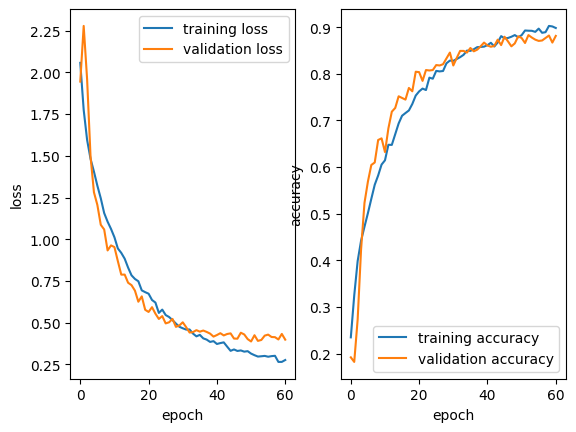

In [58]:
plt.subplot(1,2,1)
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training loss', 'validation loss'])

plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['training accuracy', 'validation accuracy'])

In [59]:
y_pred = model3.predict(X_val)
y_pred_ = np.argmax(y_pred, axis = 1)
y_val_ = np.argmax(y_val, axis = 1)
print(classification_report(y_val_, y_pred_))
     

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       160
           1       0.77      0.93      0.84       160
           2       0.82      0.87      0.84       160
           3       0.91      0.84      0.87       160
           4       0.91      0.80      0.85       160
           5       0.81      0.79      0.80       160
           6       0.91      0.85      0.88       160

    accuracy                           0.86      1120
   macro avg       0.86      0.86      0.86      1120
weighted avg       0.86      0.86      0.86      1120



Text(0, 0.5, 'Prediction')

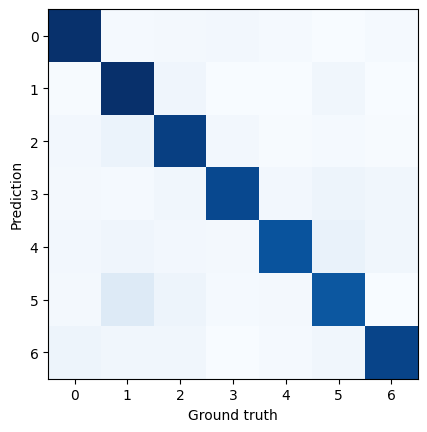

In [60]:
cm = confusion_matrix(y_val_, y_pred_)
plt.imshow(cm, cmap = plt.cm.Blues)
plt.xlabel('Ground truth')
plt.ylabel('Prediction')

In [61]:
print(top_k_accuracy_score(y_val_, y_pred, k = 2))
print(top_k_accuracy_score(y_val_, y_pred, k = 3))

0.925
0.9544642857142858


# Saving and testing
Now we may merge training set and validation set in order to re-train all of our models on a bigger set of data. Then, we'll test the performances on the test set.



In [62]:

# Clear previous models & set random seed
K.clear_session()
tf.random.set_seed(42)

# Split training data into train + validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

num_classes = 7
model2 = Sequential()

# Conv Block 1
model2.add(Conv1D(64, kernel_size=10, padding='same', input_shape=(X_train.shape[1], 1)))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Conv Block 2
model2.add(Conv1D(128, kernel_size=10, padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Conv Block 3
model2.add(Conv1D(128, kernel_size=10, padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling1D(pool_size=2))
model2.add(Dropout(0.3))

# Fully Connected
model2.add(Flatten())
model2.add(Dense(128))
model2.add(LeakyReLU(0.1))
model2.add(Dropout(0.5))

# Output layer
model2.add(Dense(num_classes, activation='softmax'))


/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
# Early stopping
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Compile the model
model2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Fit the model
history2 = model2.fit(
    X_train_final,
    y_train_final,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1968 - loss: 2.3658 - val_accuracy: 0.1902 - val_loss: 1.9011
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2992 - loss: 1.8144 - val_accuracy: 0.2348 - val_loss: 2.0429
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3628 - loss: 1.6458 - val_accuracy: 0.2902 - val_loss: 1.7893
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4186 - loss: 1.5056 - val_accuracy: 0.4536 - val_loss: 1.4092
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4634 - loss: 1.3858 - val_accuracy: 0.5027 - val_loss: 1.2857
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5001 - loss: 1.3107 - val_accuracy: 0.6027 - val_loss: 1.1254
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5399 - loss: 1.2277 - val_accuracy: 0.5964 - val_loss: 1.1216
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5639 - loss: 1.1428 - val_acc

In [64]:
y_pred = model2.predict(X_val)
y_pred_ = np.argmax(y_pred, axis = 1)
y_val_ = np.argmax(y_val, axis = 1)
print(classification_report(y_val_, y_pred_))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       160
           1       0.85      0.93      0.89       160
           2       0.82      0.89      0.85       160
           3       0.91      0.87      0.89       160
           4       0.87      0.84      0.86       160
           5       0.86      0.82      0.84       160
           6       0.86      0.91      0.88       160

    accuracy                           0.87      1120
   macro avg       0.87      0.87      0.87      1120
weighted avg       0.87      0.87      0.87      1120



In [65]:
model2.save('/home/heru/sonamyangchen/ravdess_emotion/Audio-CNN 1D_model2.h5')

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2


num_classes = 7

# Make sure input shape has channel dimension
if len(X_train_aug.shape) == 2:
    X_train_aug = np.expand_dims(X_train_aug, axis=-1)
if len(X_val.shape) == 2:
    X_val = np.expand_dims(X_val, axis=-1)

model3 = Sequential()

# Conv Block 1
model3.add(Conv1D(64, kernel_size=10, activation='relu', padding='same', input_shape=(X_train_aug.shape[1], 1)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Conv Block 2
model3.add(Conv1D(128, kernel_size=10, activation='relu', padding='same', kernel_regularizer=l2(0.001), bias_regularizer=l2(0.01)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Conv Block 3
model3.add(Conv1D(128, kernel_size=10, activation='relu', padding='same', kernel_regularizer=l2(0.001), bias_regularizer=l2(0.01)))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Dropout(0.4))

# Flatten
model3.add(Flatten())

# Dense layers
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.4))
model3.add(Dense(num_classes, activation='softmax'))

model3.summary()


/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,895 (1.95 MB)

 Trainable params: 509,895 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Compile
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Fit
history3 = model3.fit(
    X_train_aug, y_train_aug,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[stop_early],
    verbose=1
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1914 - loss: 2.1305 - val_accuracy: 0.3036 - val_loss: 1.8603
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3149 - loss: 1.8450 - val_accuracy: 0.4125 - val_loss: 1.6422
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4215 - loss: 1.6324 - val_accuracy: 0.4875 - val_loss: 1.4989
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4660 - loss: 1.5131 - val_accuracy: 0.5277 - val_loss: 1.3621
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5216 - loss: 1.4017 - val_accuracy: 0.5857 - val_loss: 1.2880
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5236 - loss: 1.3482 - val_accuracy: 0.6259 - val_loss: 1.2245
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5637 - loss: 1.2982 - val_accuracy: 0.6562 - val_loss: 1.1583
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5871 - loss: 1.2244 - val_acc

In [68]:
y_pred = model3.predict(X_val)
y_pred_ = np.argmax(y_pred, axis = 1)
y_val_ = np.argmax(y_val, axis = 1)
print(classification_report(y_val_, y_pred_))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       160
           1       0.80      0.91      0.85       160
           2       0.75      0.86      0.80       160
           3       0.92      0.77      0.84       160
           4       0.89      0.83      0.86       160
           5       0.81      0.78      0.80       160
           6       0.90      0.82      0.86       160

    accuracy                           0.84      1120
   macro avg       0.84      0.84      0.84      1120
weighted avg       0.84      0.84      0.84      1120



In [69]:
model3.save('/home/heru/sonamyangchen/ravdess_emotion/Audio-CNN 1D_model3.h5')